Предмет "Искусственный интеллект"

Лабораторная работа №3

Грибушенков Михаил, группа РФЗ-2-2022

Кластеризация белых вин.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# defines
filename = "winequality-white[1].csv"

In [4]:
db = pd.read_csv (filename, sep=";") # Загрузка базы данных из файла
db.info() # Статистика по БД
# Нормализация датасета из предыдущей работы...
for column in db.columns:
    db[column] = db[column] / db[column].abs().max()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


Нормализованное.

<Axes: >

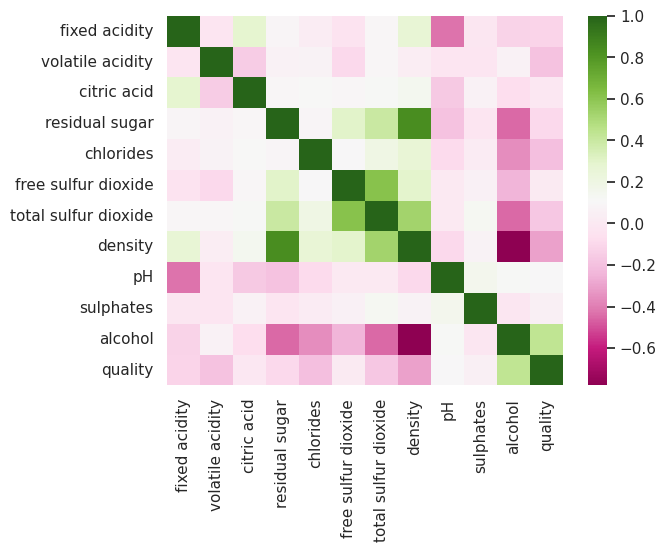

In [ ]:
sns.heatmap(db.corr(numeric_only = True), cmap="PiYG")

Видно, что с субъективной оценкой quality сильнее всего коррелируют крепость вина, плотность, "chlorides" и "volatile acidity", прочее коррелирует примерно одинаково, кроме pH, от которого оценнка почти не зависит.

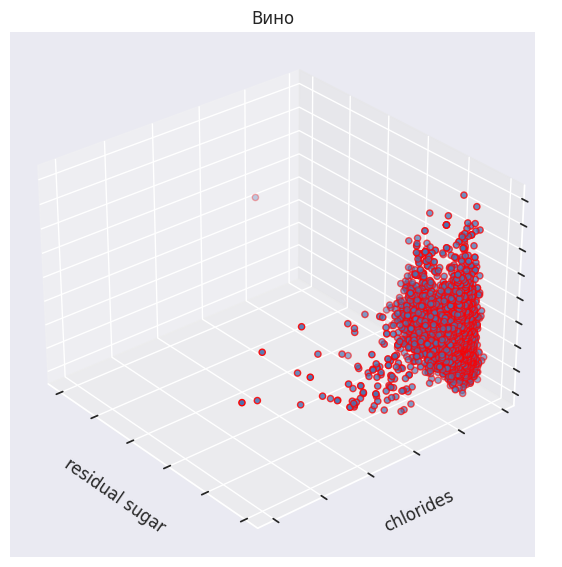

In [ ]:
# Вручную подобрали признаки, на которых выделяются некие кластеры
fig = plt.figure (figsize=(15, 15))
ax = fig.add_subplot (2, 2, 4, projection="3d", elev=30, azim=140)
ax.scatter (db["residual sugar"], db["chlorides"], db["sulphates"], edgecolor="red")

ax.xaxis.set_ticklabels ([])
ax.yaxis.set_ticklabels ([])
ax.zaxis.set_ticklabels ([])
ax.set_xlabel ("residual sugar")
ax.set_ylabel ("chlorides")
ax.set_zlabel ("sulphates")
ax.set_title ("Вино")

plt.show ()

In [ ]:
from sklearn.cluster import KMeans
from contextlib import nullcontext
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score

# Поиск оптимального числа кластеров
n_clusters = np.arange(2, 50)
best_silhouette = 88005553535
best_cluster_centers = []
best_metrics_n = 0

silhouette_score_values = []

for n in n_clusters:
    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(db)
    y_pred = clusterer.predict(db)

    silhouette = metrics.silhouette_score(db, y_pred)
    silhouette_score_values.append(silhouette)

    if silhouette < best_silhouette:
          best_silhouette = silhouette
          best_cluster_centers = clusterer.cluster_centers_
          best_metric_n = n



In [ ]:
print ("Лучшее число кластеров: ", best_metric_n)

Лучшее число кластеров:  35


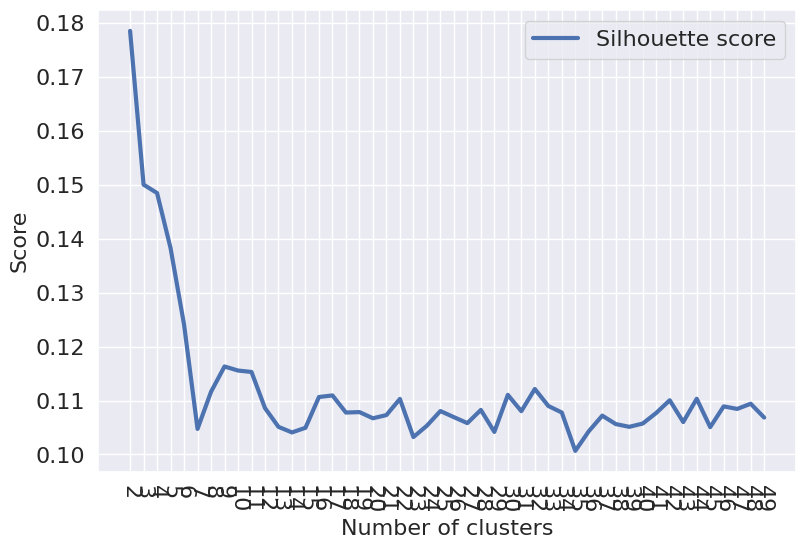

In [ ]:
# Визуализация результата поиска оптимального числа кластеров

plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16, rotation=-90)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()

Лучшая оценка силуэта получается для 35 категорий, но число 7 маленькое, не так далеко от 35 и мне больше нравится.

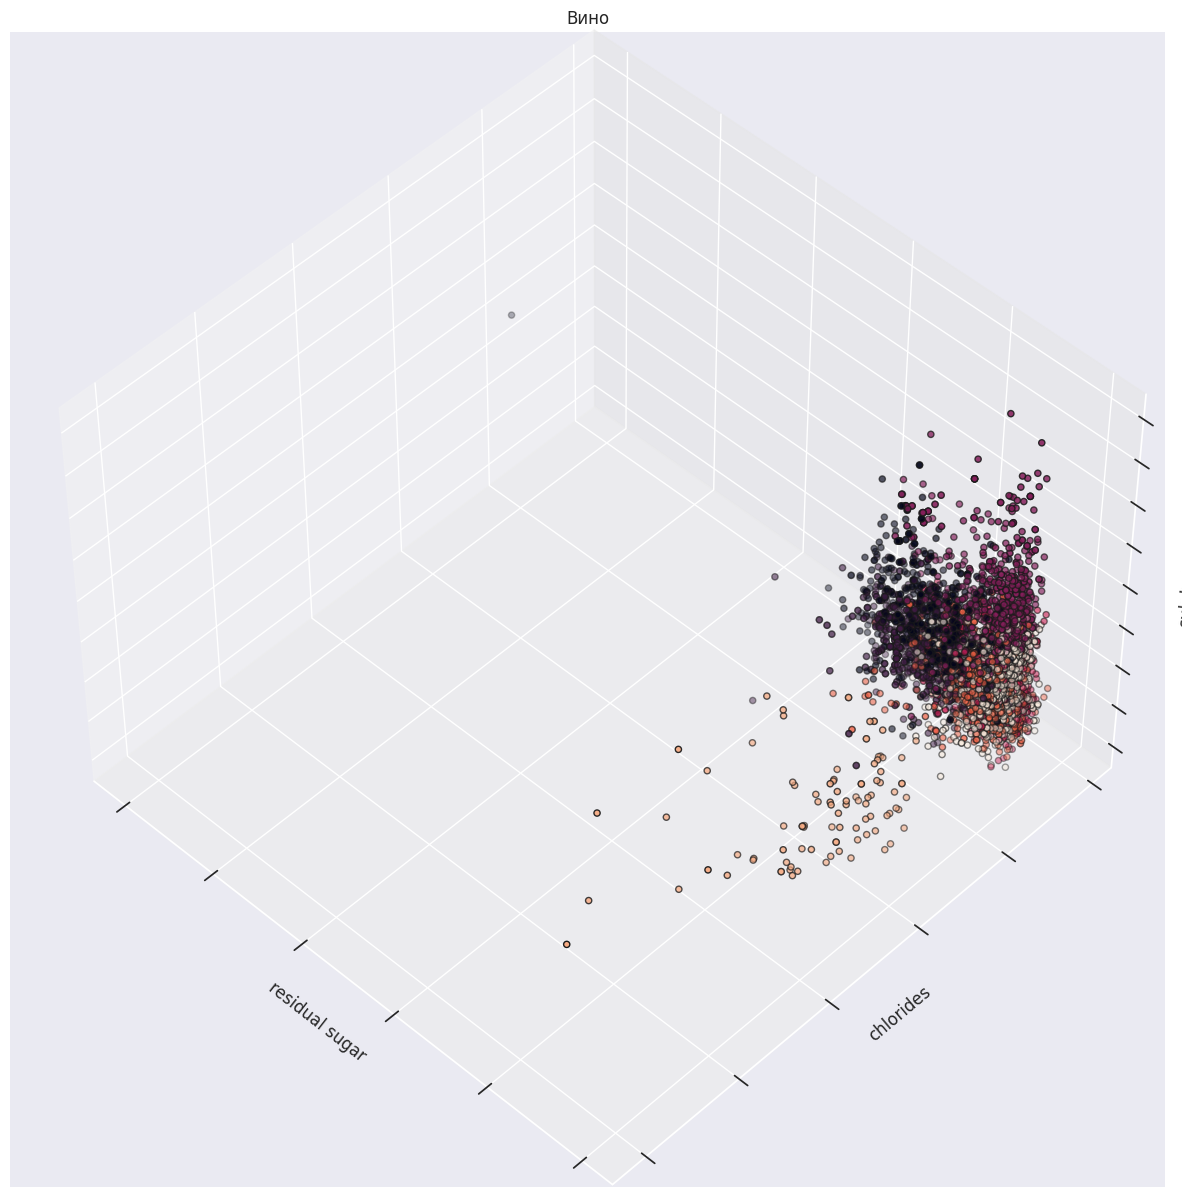

In [ ]:
# Визуализация датасета
est = KMeans(n_clusters=7, max_iter=10, n_init=10)
est.fit(db)

fig = plt.figure (figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter (db["residual sugar"], db["chlorides"], db["sulphates"],
            c=est.labels_.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels ([])
ax.yaxis.set_ticklabels ([])
ax.zaxis.set_ticklabels ([])
ax.set_xlabel ("residual sugar")
ax.set_ylabel ("chlorides")
ax.set_zlabel ("sulphates")
ax.set_title ("Вино")

plt.show()

# Вот так как-то. Семь групп вин, из них три визуально выделяются.

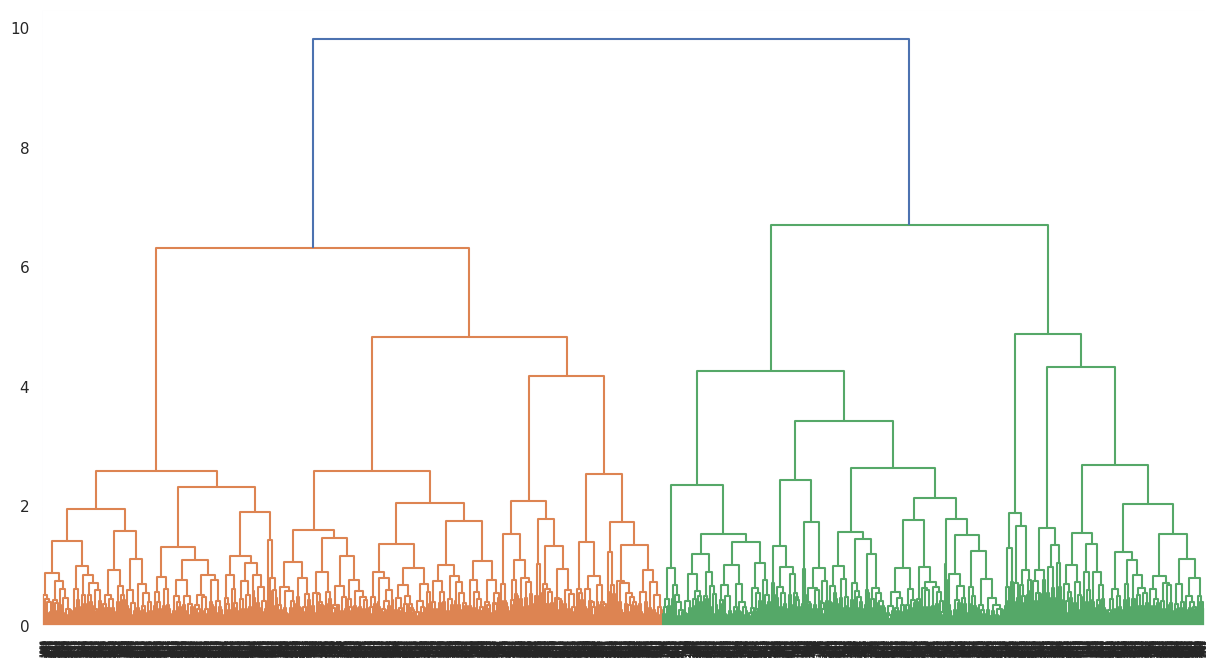

In [ ]:
# Иерархическая кластеризация

from scipy.cluster.hierarchy import linkage, dendrogram
samples = db.values
mergings = linkage(samples, method='ward')

plt.figure(figsize=(15, 8))

dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

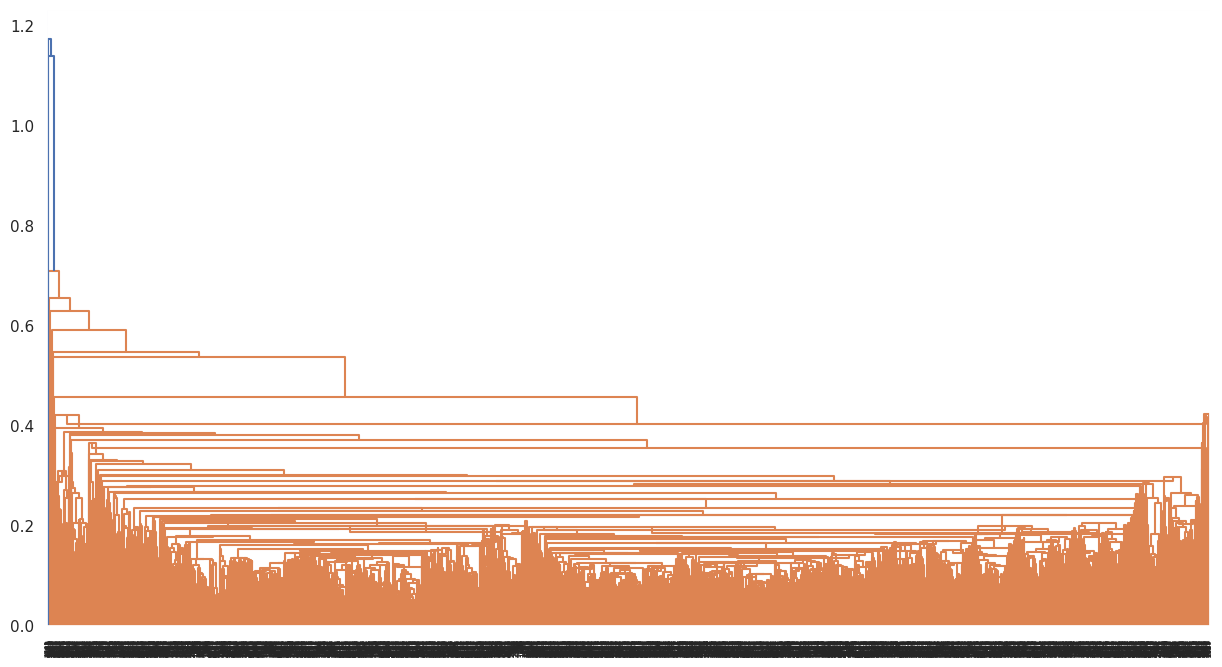

In [ ]:
# Другой метод

from scipy.cluster.hierarchy import linkage, dendrogram
samples = db.values
mergings = linkage(samples, method='centroid')

plt.figure(figsize=(15, 8))

dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

# Получается не такая красивая дендрограмма

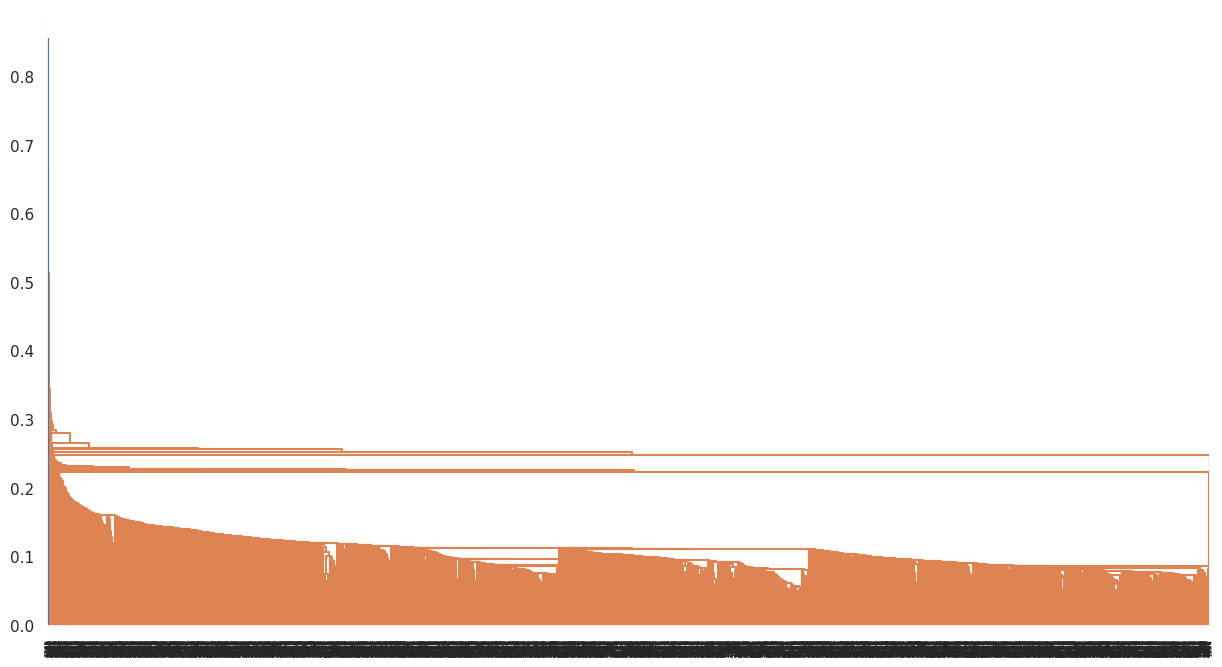

In [ ]:
# Другой метод

from scipy.cluster.hierarchy import linkage, dendrogram
samples = db.values
mergings = linkage(samples, method='single')

plt.figure(figsize=(15, 8))

dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

# Снова получается не такая красивая дендрограмма

In [24]:
# Попробуем метод dbscan

from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

mins = db.shape[1]

dbscan = DBSCAN(eps=0.30, min_samples=15).fit(db)
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True


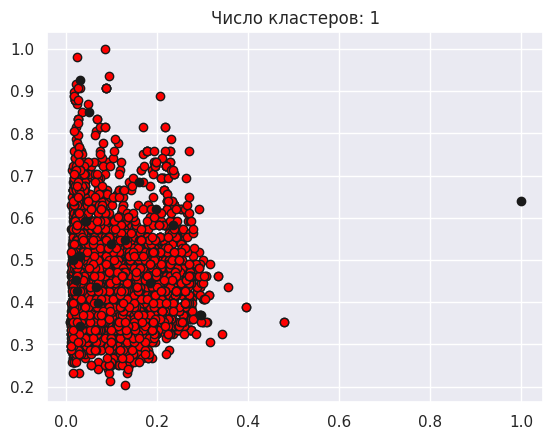

Оценка силуэта: 0.56


In [25]:
labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = set(labels)
colors = ["red", "green", "blue", "yellow", "magenta"]

for k, col in zip(unique_labels, colors):
	if k == -1:
		# Black used for noise.
		col = 'k'

	class_member_mask = (labels == k)

	xy = db[class_member_mask & core_samples_mask]
	plt.plot(xy["residual sugar"], xy["sulphates"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

	xy = db[class_member_mask & ~core_samples_mask]
	plt.plot(xy["residual sugar"], xy["sulphates"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

plt.title('Число кластеров: %d' % n_clusters_)
plt.show()

sc = metrics.silhouette_score(db, labels)
print("Оценка силуэта: %0.2f" % sc)

dbscan работает с данным набором данных плохо: точки в наборе расположенны близко друг к другу в пространстве признаков, отличаются слабо. Со значениями eps от 0,05 до 1 выделяется только один кластер, меняется лишь число выбросов. При 0,05 все данные уже выбросы.
Визуально лучший результат дают К средних при семи кластерах, проверить правильность деления, однако, не выйдет: данных о делении вин по сортам или к/л другим группам в наборе данных нет.